In [1]:
!pip install finesse

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 4.8 MB/s eta 0:00:00
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.16
    Uninstalling multiprocess-0.70.16:
      Success

In [2]:
import finesse
import numpy as np
import matplotlib.pyplot as plt
from finesse.analysis.actions import Xaxis

finesse.configure(plotting=True)

### **Base PRM Model**

The model includes the basic components of the Michelson Interferometer along with Power Recycling Mirror (PRM) between the laser source and the Beam Splitter. I added a modulator before the PRM to generate a modulation sidebands at ±80 MHz. I also placed a demodulating photodector (`pd1`) at the reflection port to get the PDH error signal by mixing the reflected carrier and sideband fields.


In [10]:
prm = finesse.Model()
prm.parse("""

    l laser1 P=125

    s s1 laser1.p1 mod.p1 L=1
    modulator mod f=80M midx=0.3 order=1
    s s2 mod.p2 PRM.p1 L=9

    m PRM R=0.9 T=0.1 phi=0

    s s_prc PRM.p2 bs1.p1 L=40
    bs bs1 R=0.5 T=0.5

    s armX bs1.p3 ETMX.p1 L=4000
    m ETMX R=1 T=0 phi=0

    s armY bs1.p2 ETMY.p1 L=4000
    m ETMY R=1 T=0 phi=0

    pd  pow_out  bs1.p4.o
    pd  pow_circ bs1.p1.o
    pd1 PDH_refl PRM.p1.o 80M 90
""")

### **Michelson Differential DoF**

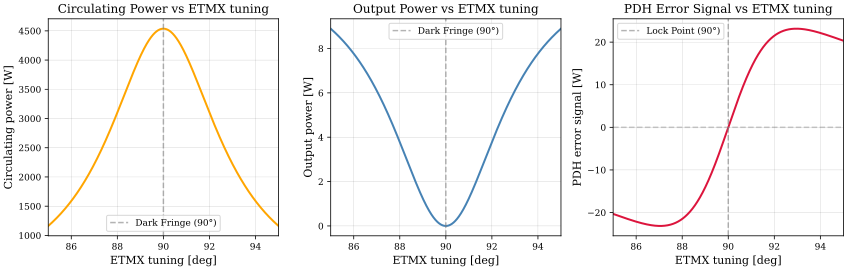

PDH error signal slope at dark fringe: 15.7001 W/deg


In [11]:
out_mich = prm.run(Xaxis("ETMX.phi", "lin", 85, 95, 1000))


fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)


axes[0].plot(out_mich.x[0], out_mich['pow_circ'], color='orange', linewidth=2)
axes[0].axvline(90, color='gray', linestyle='--', alpha=0.6, label='Dark Fringe (90°)')
axes[0].set_ylabel('Circulating power [W]')
axes[0].set_xlabel('ETMX tuning [deg]')
axes[0].set_title('Circulating Power vs ETMX tuning')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(out_mich.x[0], out_mich['pow_out'], color='steelblue', linewidth=2)
axes[1].axvline(90, color='gray', linestyle='--', alpha=0.6, label='Dark Fringe (90°)')
axes[1].set_ylabel('Output power [W]')
axes[1].set_xlabel('ETMX tuning [deg]')
axes[1].set_title('Output Power vs ETMX tuning')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

axes[2].plot(out_mich.x[0], out_mich['PDH_refl'], color='crimson', linewidth=2)
axes[2].axvline(90, color='gray', linestyle='--', alpha=0.6, label='Lock Point (90°)')
axes[2].axhline(0,  color='gray', linestyle='--', alpha=0.4)
axes[2].set_ylabel('PDH error signal [W]')
axes[2].set_xlabel('ETMX tuning [deg]')
axes[2].set_title('PDH Error Signal vs ETMX tuning')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


phi = out_mich.x[0]
pdh = out_mich['PDH_refl']
idx = np.argmin(np.abs(phi - 90.0))
slope = np.gradient(pdh, phi)[idx]

print(f"PDH error signal slope at dark fringe: {slope:.4f} W/deg")

The ETMX is swept while the ETMY is kept fixed. Changing the ETMX tuning creates a relative phase change between the interferometer arms, causing a small differential arm length change.

1. Circulating Power vs ETMX tuning: At the dark fringe, the circulating power reaches nearly 4500 W. The PRM causes light to build up inside the recycling cavity.

2. Output Power vs ETMX Tuning: At 90°, the graph is parabolic, confirming the interference at the dark fringe condition.

3. PDH error signal vs ETMX Tuning: It is an antisymmetric plot. It isn't perfectly linear across the whole sweep but is only linear near the lock-point. This allows us to apply appropriate force to push the signal towards 0 on either side.


According to Black's paper, the laser is split into a carrier ($\omega$) and two RF sidebands ($\omega \pm \Omega$). Having a demodulation detector ( `pd1` at $80\text{ MHz}$) extract the low-frequency signal, producing PDH error using interfeormeter sensing and locking. After demodulation, the error signal is proportional to the imaginary part of the cavity reflection coefficient, which is antisymmetric around resonance and thus the PDH plot is S-shaped curve.

The calculated slope of the PDH signal near the operating point confirms that the interferometer can be actively locked.


### **Power Recycling Cavity Length DoF**

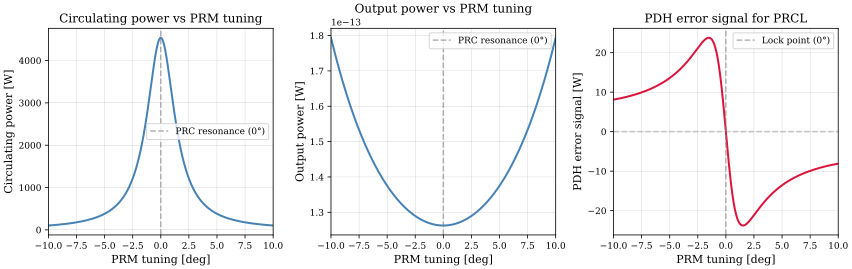

PRCL PDH slope at lock point: -31.3951 W/deg


In [13]:
prm.ETMX.phi = 90.0

out_prcl = prm.run(Xaxis("PRM.phi", "lin", -10, 10, 1000))

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)

axes[0].plot(out_prcl.x[0], out_prcl['pow_circ'], color='steelblue', linewidth=2)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.6, label='PRC resonance (0°)')
axes[0].set_ylabel('Circulating power [W]')
axes[0].set_xlabel('PRM tuning [deg]')
axes[0].set_title('Circulating power vs PRM tuning')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(out_prcl.x[0], out_prcl['pow_out'], color='steelblue', linewidth=2)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.6, label='PRC resonance (0°)')
axes[1].set_ylabel('Output power [W]')
axes[1].set_xlabel('PRM tuning [deg]')
axes[1].set_title('Output power vs PRM tuning')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

axes[2].plot(out_prcl.x[0], out_prcl['PDH_refl'], color='crimson', linewidth=2)
axes[2].axvline(0, color='gray', linestyle='--', alpha=0.6, label='Lock point (0°)')
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.4)
axes[2].set_ylabel('PDH error signal [W]')
axes[2].set_xlabel('PRM tuning [deg]')
axes[2].set_title('PDH error signal for PRCL')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

phi   = out_prcl.x[0]
pdh   = out_prcl['PDH_refl']
idx   = np.argmin(np.abs(phi - 0.0))
slope = np.gradient(pdh, phi)[idx]
print(f"PRCL PDH slope at lock point: {slope:.4f} W/deg")

I tuned the PRM while keeping the interferometer arms fixed. PRC is the cavity between the PRM and the BS. Tuning the PRM modifies the cavity resonance condition, and thus changes the circulating power.

With both arm mirrors at their default tuning ($\phi=0$), the PRC resonance condition is satisfied at `PRM.phi = 0°`. The ETMX mirror is held at 90° (the dark fringe condition) while the PRM is swept,  the Michelson remains at its operating point.

1. Circulating Power vs PRM Tuning: The cavity length ensures the light constructively interferes and the power is maximum.

2. Output Power vs PRM Tuning: The power is minimised as almost all carrier light is reflected back toward the laser.

3. PDH Error Signal for PRCL: The zero-crossing of the PDH signal signifies the lock point for the PRCL DoF.